# IIR Filters Under Mixed Precision

This notebook explores how the six analog-prototype IIR families exposed by `mpdsp` behave when processing and coefficients are quantized to a reduced-precision number type. It mirrors the precision-sweep tables produced by the C++ test driver, using the Python bindings.

For each filter we measure:

- **SQNR** of the filtered output vs. the double-precision reference, per dtype
- **Pole displacement** caused by quantizing the biquad coefficients
- **Condition number** and **worst-case sensitivity** as design-time indicators of numerical fragility

Arithmetic configurations are the pre-instantiated ones from `mpdsp.available_dtypes()`: `reference`, `gpu_baseline`, `ml_hw`, `cf24`, `half`, `posit_full`, `tiny_posit`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mpdsp
from mpdsp.filters import compare_filters, plot_filter_comparison

mpdsp.available_dtypes()

['reference',
 'gpu_baseline',
 'ml_hw',
 'posit_full',
 'tiny_posit',
 'cf24',
 'half']

## Test signal

A two-tone test: a 200 Hz passband tone plus a 3 kHz stopband tone, sampled at 8 kHz. This lets us see passband preservation and stopband rejection in one plot.

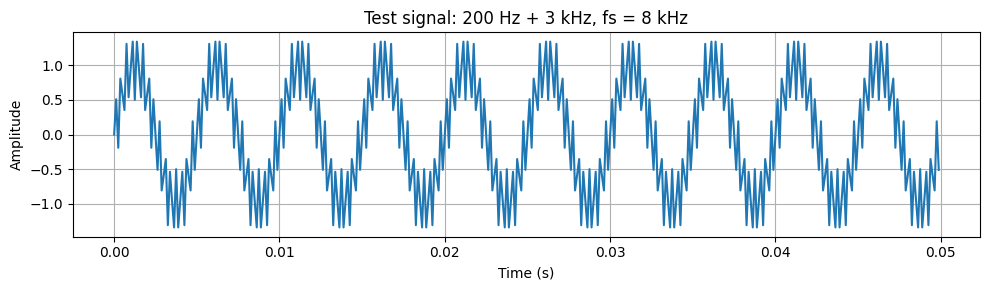

In [2]:
SAMPLE_RATE = 8000.0
N = 4096

t = np.arange(N) / SAMPLE_RATE
signal = np.sin(2 * np.pi * 200 * t) + 0.5 * np.sin(2 * np.pi * 3000 * t)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:400], signal[:400])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Test signal: 200 Hz + 3 kHz, fs = 8 kHz')
ax.grid(True)
fig.tight_layout();

## A single filter across all dtypes

Start with a sixth-order Butterworth lowpass at 1 kHz. `compare_filters` runs the signal through each dtype and reports SQNR (dB) and max absolute / relative error vs the `reference` (double-precision) output.

In [3]:
butter = mpdsp.butterworth_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0)

df = compare_filters(butter, signal)
df

,dtype,sqnr_db,max_abs_error,max_rel_error,error
0,reference,300.000000,0.000000e+00,0.000000e+00,None
1,gpu_baseline,133.865454,2.645941e-07,2.648958e-07,None
2,ml_hw,70.501584,4.829334e-04,4.834841e-04,None
3,cf24,109.346832,7.027696e-06,7.035709e-06,None
4,half,61.672524,1.151157e-03,1.152469e-03,None
5,posit_full,73.993739,3.259467e-04,3.263183e-04,None
6,tiny_posit,12.578543,4.379987e-01,4.384981e-01,None


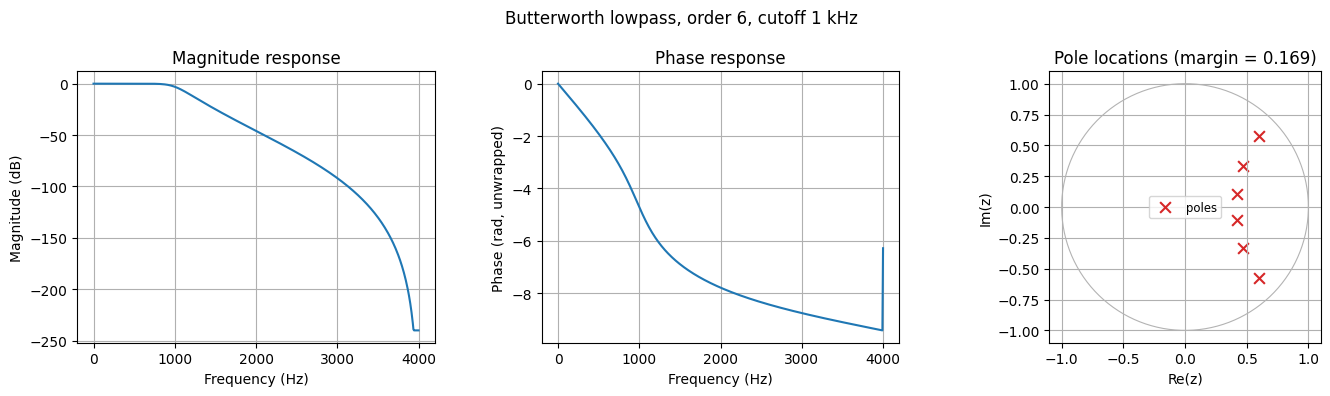

In [4]:
fig = plot_filter_comparison(butter, num_freqs=512, sample_rate=SAMPLE_RATE,
                             title='Butterworth lowpass, order 6, cutoff 1 kHz')
fig.set_size_inches(14, 4);

## Sweep across all six IIR families

Design each family at the same spec (lowpass, order 6, 1 kHz cutoff) and compare dtype-induced error. Chebyshev I takes a passband ripple; Chebyshev II a stopband attenuation; Elliptic takes both ripple and a selectivity parameter `rolloff`.

In [5]:
families = {
    'butterworth': mpdsp.butterworth_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0),
    'chebyshev1':  mpdsp.chebyshev1_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0, ripple_db=1.0),
    'chebyshev2':  mpdsp.chebyshev2_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0, stopband_db=40.0),
    'bessel':      mpdsp.bessel_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0),
    'legendre':    mpdsp.legendre_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0),
    'elliptic':    mpdsp.elliptic_lowpass(order=6, sample_rate=SAMPLE_RATE, cutoff=1000.0, ripple_db=1.0, rolloff=1.0),
}

rows = []
for name, filt in families.items():
    df_f = compare_filters(filt, signal)
    for _, r in df_f.iterrows():
        rows.append({'family': name, 'dtype': r['dtype'], 'sqnr_db': r['sqnr_db']})

sqnr_table = pd.DataFrame(rows).pivot(index='family', columns='dtype', values='sqnr_db')
sqnr_table = sqnr_table[['reference', 'gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full', 'tiny_posit']]
sqnr_table.round(1)

dtype,reference,gpu_baseline,ml_hw,cf24,half,posit_full,tiny_posit
family,,,,,,,
bessel,300.0,144.0,69.2,108.2,60.4,77.9,18.7
butterworth,300.0,133.9,70.5,109.3,61.7,74.0,12.6
chebyshev1,300.0,126.3,74.1,97.9,49.1,69.2,7.6
chebyshev2,300.0,130.4,74.0,102.7,57.0,83.2,5.6
elliptic,300.0,123.4,74.1,88.2,54.1,69.5,-1.5
legendre,300.0,133.4,67.9,103.8,50.8,66.8,6.8


The `reference` column is effectively infinite SQNR (capped at 300 dB in the binding) because it's compared to itself. The interesting columns are the quantized ones: they show how aggressively each family loses fidelity.

Elliptic and Chebyshev I typically lose the most — both have high-Q poles near the unit circle where coefficient quantization causes large pole movements. Bessel and Butterworth, with more spread-out poles, tolerate quantization better.

## Pole displacement per dtype

`stability_margin` and `pole_displacement(dtype)` quantify directly what the SQNR numbers suggest indirectly. The margin is `1 - max(|pole|)`; the displacement is the max distance each pole moves when coefficients are stored at the target precision.

In [6]:
dtypes = ['gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full', 'tiny_posit']

rows = []
for name, filt in families.items():
    row = {'family': name, 'stability_margin': filt.stability_margin()}
    for dt in dtypes:
        row[dt] = filt.pole_displacement(dt)
    rows.append(row)

displacement = pd.DataFrame(rows).set_index('family')
displacement.round(6)

,stability_margin,gpu_baseline,ml_hw,cf24,half,posit_full,tiny_posit
family,,,,,,,
butterworth,0.168977,0.0,0.000169,0.000000,0.000169,0.0,0.043412
chebyshev1,0.043100,0.0,0.000607,0.000002,0.000607,0.0,0.057346
chebyshev2,0.097192,0.0,0.000333,0.000002,0.000333,0.0,0.035666
bessel,0.326275,0.0,0.000111,0.000001,0.000111,0.0,0.028898
legendre,0.078729,0.0,0.001340,0.000003,0.001340,0.0,0.157532
elliptic,0.042520,0.0,0.000364,0.000006,0.000364,0.0,0.059308


Smaller `stability_margin` + larger displacement = a filter that's close to becoming unstable under quantization. For critical-precision designs this is the column to watch.

## Condition number vs order

Higher-order cascades amplify coefficient error. Sweeping order and measuring `condition_number` gives a quick view of how quickly the numerical picture degrades as you push selectivity up.

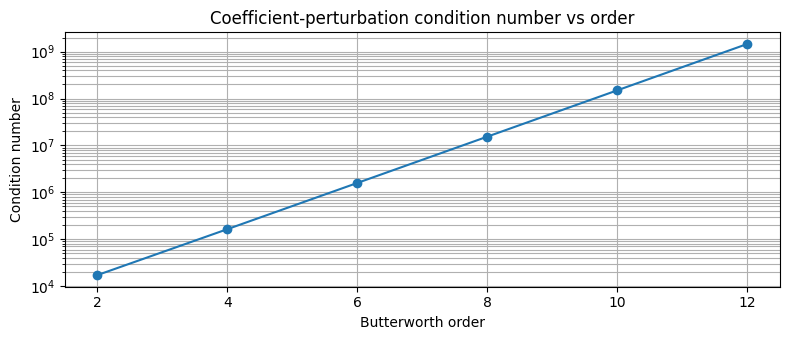

In [7]:
orders = list(range(2, 13, 2))
cns = []
for k in orders:
    f = mpdsp.butterworth_lowpass(order=k, sample_rate=SAMPLE_RATE, cutoff=1000.0)
    cns.append(f.condition_number(num_freqs=128))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogy(orders, cns, 'o-')
ax.set_xlabel('Butterworth order')
ax.set_ylabel('Condition number')
ax.set_title('Coefficient-perturbation condition number vs order')
ax.grid(True, which='both');
fig.tight_layout();

## A precision-marginal case: 12th-order elliptic

The combination of a steep elliptic transition and a high order pushes the filter into the regime where low-precision types break down.

In [8]:
hard = mpdsp.elliptic_lowpass(order=12, sample_rate=SAMPLE_RATE, cutoff=1200.0,
                              ripple_db=0.5, rolloff=2.0)

print(f'stability margin      = {hard.stability_margin():.4f}')
print(f'worst-case sensitivity = {hard.worst_case_sensitivity():.3f}')
print(f'condition number      = {hard.condition_number():.2e}')

compare_filters(hard, signal)

stability margin      = 0.0155
worst-case sensitivity = 0.581
condition number      = 6.39e+10


,dtype,sqnr_db,max_abs_error,max_rel_error,error
0,reference,3.000000e+02,0.000000,0.000000,None
1,gpu_baseline,1.159373e+02,0.000002,0.000002,None
2,ml_hw,3.671995e+01,0.025210,0.025328,None
3,cf24,7.333892e+01,0.000459,0.000461,None
4,half,1.988406e+01,0.130836,0.131445,None
5,posit_full,3.215131e+01,0.042643,0.042841,None
6,tiny_posit,-6.654861e-07,0.995371,1.000001,None


For this filter `tiny_posit` and `half` produce nothing resembling the reference output. `cf24` and `posit_full` hold together. The lesson: the arithmetic configuration has to match the dynamic range of the filter design — high-Q elliptic cascades need wide coefficients.

## Takeaways

- **Filter family matters as much as dtype.** Bessel and Butterworth stay usable in half-precision; Elliptic and Chebyshev I often don't.
- **Condition number is the cheapest proxy for precision requirements** — you can compute it from the design alone, without processing a signal.
- **`pole_displacement` tells you *which* poles are quantization-sensitive**, which is actionable: it can motivate restructuring a long cascade into lower-order sub-cascades that are individually tolerant.
- The `mpdsp.filters.compare_filters` / `plot_filter_comparison` helpers make dtype sweeps a one-liner — see the FIR notebook (`03_fir_and_windows.ipynb`) for the equivalent workflow on finite-impulse-response designs.